<a href="https://colab.research.google.com/github/NETSADOM/Enzyme-Function-Classification-from-Protein-Sequence-/blob/main/Enzyme_Classification_from_Sequence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets lightgbm imbalanced-learn shap scikit-learn matplotlib seaborn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import re
from collections import Counter
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, matthews_corrcoef, accuracy_score, average_precision_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE
import shap

import warnings
warnings.filterwarnings('ignore')

In [ ]:
print("Loading dataset...")
try:
    dataset = load_dataset("DanielHesslow/SwissProt-EC")
    df = pd.DataFrame(dataset['train'])
    print(f"Loaded Hugging Face dataset. Shape: {df.shape}")
except Exception as e:
    print(f"Error loading HF dataset: {e}")

Loading dataset...


README.md:   0%|          | 0.00/522 [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 85.3MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/dev-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/208823 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25892 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/26724 [00:00<?, ? examples/s]

Loaded Hugging Face dataset. Shape: (208823, 4)


In [ ]:
def extract_first_ec(ec_string):
    if pd.isna(ec_string):
        return None
    if isinstance(ec_string, list):
        if len(ec_string) > 0:
            ec = ec_string[0]
        else:
            return None
    else:
        ec = str(ec_string)

    match = re.search(r'EC:(\d+)', ec)
    if match:
        digit = int(match.group(1))
        if 1 <= digit <= 6:
            return digit
    return None

df['EC1'] = df['labels_str'].apply(extract_first_ec)
df = df.dropna(subset=['EC1'])
df['EC1'] = df['EC1'].astype(int)
df = df.drop_duplicates(subset=['seq'])

print("Dataset size after cleaning:", len(df))
print("Class distribution:")
print(df['EC1'].value_counts())

# Sampling to make it manageable in Colab session (Adjust SAMPLE_SIZE as needed)
SAMPLE_SIZE = 10000
if len(df) > SAMPLE_SIZE:
    # Calculate class proportions
    class_proportions = df['EC1'].value_counts(normalize=True)

    # Initialize an empty list to collect sampled dataframes
    sampled_dfs = []

    # Iterate over each class and sample from it
    for class_val in class_proportions.index:
        proportion = class_proportions[class_val]
        num_samples_for_class = round(SAMPLE_SIZE * proportion)

        class_df = df[df['EC1'] == class_val]

        # Ensure we don't try to sample more than available in the class
        # And ensure at least one sample if the class is not empty and calculated samples is 0
        num_samples_for_class = min(
            max(int(num_samples_for_class), 1) if num_samples_for_class == 0 and not class_df.empty else int(num_samples_for_class),
            len(class_df)
        )

        if num_samples_for_class > 0:
            sampled_dfs.append(class_df.sample(n=num_samples_for_class, random_state=42))

    # Concatenate all sampled dataframes and shuffle
    if sampled_dfs:
        df = pd.concat(sampled_dfs).sample(frac=1, random_state=42).reset_index(drop=True)
        print(f"\nSampled down to {SAMPLE_SIZE} for feasible processing time in this session (stratified manually).")
    else:
        print(f"\nCould not perform stratified sampling. Keeping original dataset size: {len(df)}")
else:
    print(f"\nDataset size ({len(df)}) is already less than or equal to SAMPLE_SIZE ({SAMPLE_SIZE}). No sampling performed.")

Dataset size after cleaning: 169682
Class distribution:
EC1
2    62824
3    40306
1    22300
6    19481
4    15671
5     9100
Name: count, dtype: int64

Sampled down to 10000 for feasible processing time in this session (stratified manually).


In [ ]:
X = df['seq'].values
y = df['EC1'].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (6999,)
Validation shape: (1500,)
Test shape: (1500,)


In [ ]:
from itertools import product
from sklearn.feature_extraction.text import CountVectorizer

amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
dipeptides = [''.join(p) for p in product(amino_acids, repeat=2)]
tripeptides = [''.join(p) for p in product(amino_acids, repeat=3)]

def calculate_aac(seq):
    counts = Counter(seq)
    length = len(seq) if len(seq) > 0 else 1
    return [counts.get(aa, 0) / length for aa in amino_acids]

def calculate_dpc(seq):
    length = len(seq) - 1 if len(seq) > 1 else 1
    di_counts = Counter([seq[i:i+2] for i in range(len(seq)-1)])
    return [di_counts.get(dp, 0) / length for dp in dipeptides]

def extract_standard_features(sequences):
    features = []
    for seq in sequences:
        seq = re.sub(r'[^ACDEFGHIKLMNPQRSTVWY]', '', seq.upper())
        aac = calculate_aac(seq)
        dpc = calculate_dpc(seq)
        features.append(aac + dpc)
    return np.array(features)

print("Extracting AAC and DPC features...")
X_train_std = extract_standard_features(X_train)
X_val_std = extract_standard_features(X_val)
X_test_std = extract_standard_features(X_test)

def get_kmers(seq, k=3):
    seq = re.sub(r'[^ACDEFGHIKLMNPQRSTVWY]', '', seq.upper())
    return ' '.join([seq[i:i+k] for i in range(len(seq)-k+1)])

print("Extracting Tripeptide 3-mers...")
X_train_3mers = [get_kmers(seq) for seq in X_train]
X_val_3mers = [get_kmers(seq) for seq in X_val]
X_test_3mers = [get_kmers(seq) for seq in X_test]

vectorizer = CountVectorizer(vocabulary=tripeptides, lowercase=False)
X_train_tri_counts = vectorizer.fit_transform(X_train_3mers)
X_val_tri_counts = vectorizer.transform(X_val_3mers)
X_test_tri_counts = vectorizer.transform(X_test_3mers)

print("Applying TruncatedSVD Embedding...")
svd = TruncatedSVD(n_components=128, random_state=42)
X_train_embed = svd.fit_transform(X_train_tri_counts)
X_val_embed = svd.transform(X_val_tri_counts)
X_test_embed = svd.transform(X_test_tri_counts)

X_train_final = np.hstack((X_train_std, X_train_embed))
X_val_final = np.hstack((X_val_std, X_val_embed))
X_test_final = np.hstack((X_test_std, X_test_embed))

print("Final Train feature shape:", X_train_final.shape)


Extracting AAC and DPC features...
Extracting Tripeptide 3-mers...
Applying TruncatedSVD Embedding...
Final Train feature shape: (6999, 548)


In [ ]:
print("Class distribution before SMOTE:", Counter(y_train))
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final, y_train)
print("Class distribution after SMOTE:", Counter(y_train_resampled))


Class distribution before SMOTE: Counter({np.int64(1): 2591, np.int64(2): 1662, np.int64(0): 920, np.int64(5): 804, np.int64(3): 647, np.int64(4): 375})
Class distribution after SMOTE: Counter({np.int64(2): 2591, np.int64(1): 2591, np.int64(4): 2591, np.int64(0): 2591, np.int64(3): 2591, np.int64(5): 2591})


In [ ]:

print("Training Random Forest...")
rf_params = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]}
rf_model = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                              rf_params, cv=5, n_iter=3, scoring='f1_macro', random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)
print("Best RF params:", rf_model.best_params_)

print("\nTraining LightGBM...")
lgb_params = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1]}
lgb_model = RandomizedSearchCV(LGBMClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
                               lgb_params, cv=5, n_iter=3, scoring='f1_macro', random_state=42)
lgb_model.fit(X_train_resampled, y_train_resampled)
print("Best LGBM params:", lgb_model.best_params_)

print("\nTraining SVM...")
svm_params = {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']}
sample_idx = np.random.choice(len(X_train_resampled), min(3000, len(X_train_resampled)), replace=False)
svm_model = RandomizedSearchCV(SVC(probability=True, random_state=42, class_weight='balanced'),
                               svm_params, cv=5, n_iter=2, scoring='f1_macro', random_state=42)
svm_model.fit(X_train_resampled[sample_idx], y_train_resampled[sample_idx])
print("Best SVM params:", svm_model.best_params_)


Training Random Forest...
Best RF params: {'n_estimators': 200, 'max_depth': 20}

Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.229469 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 139740
[LightGBM] [Info] Number of data points in the train set: 12436, number of used features: 548
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.212051 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 139740
[LightGBM] [Info] Number of data points in the train set: 12437, number of used fea

In [ ]:
best_rf = rf_model.best_estimator_
best_lgb = lgb_model.best_estimator_
best_svm = svm_model.best_estimator_

print("Training Hard Voting Ensemble...")
hard_voting = VotingClassifier(estimators=[('rf', best_rf), ('lgb', best_lgb), ('svm', best_svm)], voting='hard')
hard_voting.fit(X_train_resampled, y_train_resampled)

print("Training Soft Voting Ensemble...")
soft_voting = VotingClassifier(estimators=[('rf', best_rf), ('lgb', best_lgb), ('svm', best_svm)], voting='soft')
soft_voting.fit(X_train_resampled, y_train_resampled)


print("Training Stacking Ensemble...")
stacking = StackingClassifier(
    estimators=[('rf', best_rf), ('lgb', best_lgb), ('svm', best_svm)],
    final_estimator=LogisticRegression(class_weight="balanced", max_iter=1000),
    cv=5
)
stacking.fit(X_train_resampled, y_train_resampled)

Training Hard Voting Ensemble...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.314959 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 139740
[LightGBM] [Info] Number of data points in the train set: 15546, number of used features: 548
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
Training Soft Voting Ensemble...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.328928 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 139740
[LightGBM] [Info] Number of data points in the train set: 15546, number of used features: 548
[LightGBM] [Info] Start tr

StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(max_depth=20,
                                                       n_estimators=200,
                                                       n_jobs=-1,
                                                       random_state=42)),
                               ('lgb',
                                LGBMClassifier(class_weight='balanced',
                                               n_estimators=200, n_jobs=-1,
                                               random_state=42)),
                               ('svm',
                                SVC(C=0.1, class_weight='balanced',
                                    kernel='linear', probability=True,
                                    random_state=42))],
                   final_estimator=LogisticRegression(class_weight='balanced',
                                                      max_iter=1000))

In [ ]:
def evaluate_model(name, model, X, y_true):
    y_pred = model.predict(X)

    macro_f1 = f1_score(y_true, y_pred, average='macro')
    mcc = matthews_corrcoef(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X)
        Y_bin = label_binarize(y_true, classes=[0,1,2,3,4,5])
        auprc = average_precision_score(Y_bin, y_prob, average='macro')
    else:
        auprc = None

    print(f"--- {name} ---")
    print(f"Macro F1: {macro_f1:.4f} | MCC: {mcc:.4f} | Accuracy: {acc:.4f}", end="")
    if auprc is not None:
        print(f" | AUPRC: {auprc:.4f}")
    else:
        print()
    return y_pred

print("=== Validation Set Results ===")
_ = evaluate_model("Random Forest", best_rf, X_val_final, y_val)
_ = evaluate_model("LightGBM", best_lgb, X_val_final, y_val)
_ = evaluate_model("SVM", best_svm, X_val_final, y_val)
_ = evaluate_model("Hard Voting", hard_voting, X_val_final, y_val)
_ = evaluate_model("Soft Voting", soft_voting, X_val_final, y_val)
_ = evaluate_model("Stacking", stacking, X_val_final, y_val)

print("\n=== Test Set Results ===")
y_test_pred = evaluate_model("Stacking (Test)", stacking, X_test_final, y_test)


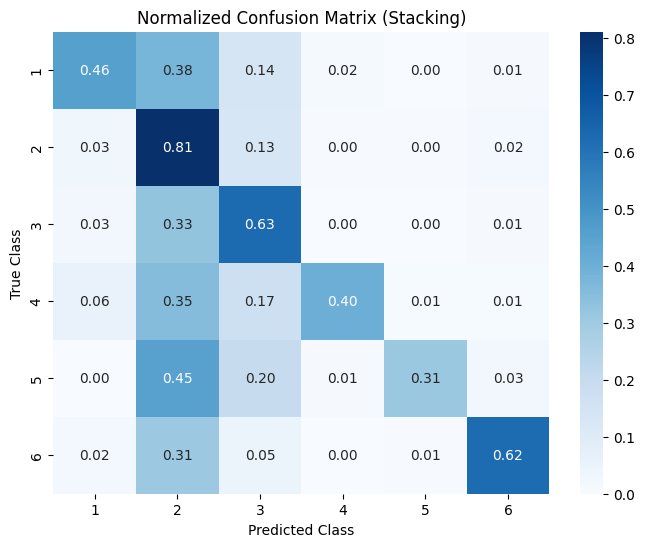

Per-Class Metrics (Stacking):

              precision    recall  f1-score   support

           1       0.69      0.46      0.55       197
           2       0.58      0.81      0.67       556
           3       0.60      0.63      0.62       356
           4       0.89      0.40      0.55       139
           5       0.86      0.31      0.46        80
           6       0.86      0.62      0.72       172

    accuracy                           0.64      1500
   macro avg       0.75      0.54      0.60      1500
weighted avg       0.67      0.64      0.63      1500



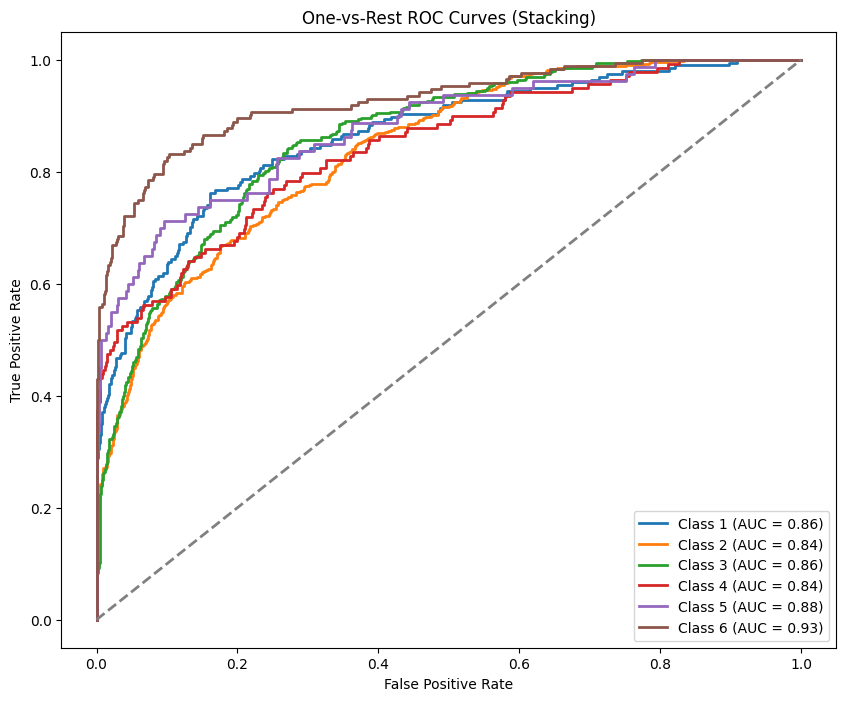

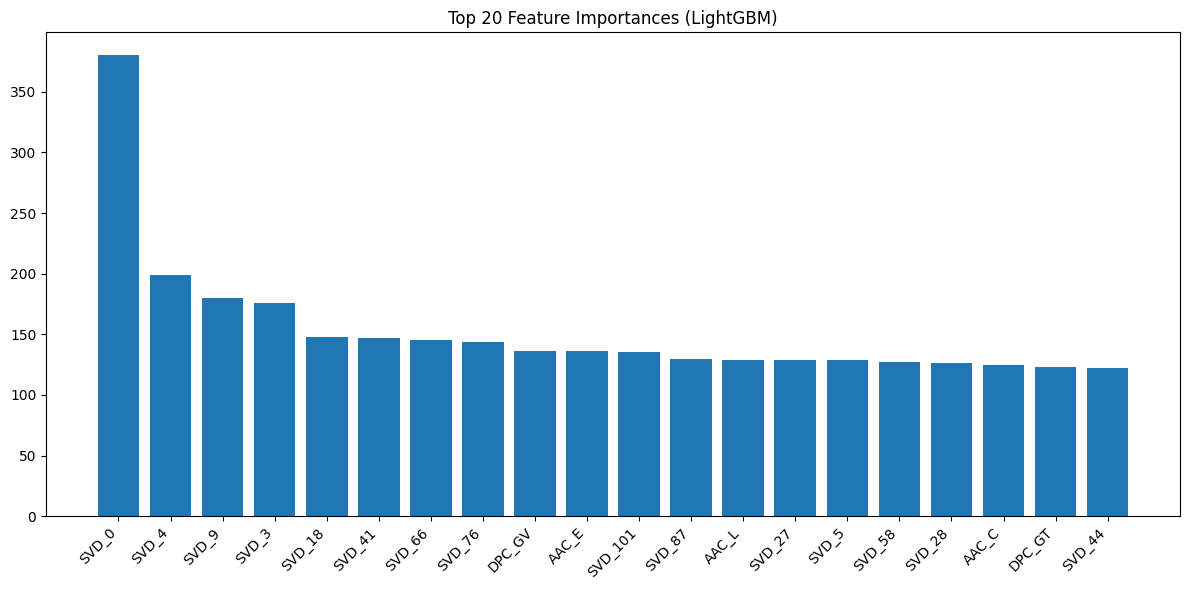

In [12]:
cm = confusion_matrix(y_test, y_test_pred, normalize='true')
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Normalized Confusion Matrix (Stacking)')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

report = classification_report(y_test, y_test_pred, target_names=[str(c) for c in label_encoder.classes_])
print("Per-Class Metrics (Stacking):\n")
print(report)

y_prob_test = stacking.predict_proba(X_test_final)
Y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4,5])

plt.figure(figsize=(10,8))
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(Y_test_bin[:, i], y_prob_test[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {label_encoder.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves (Stacking)')
plt.legend(loc="lower right")
plt.show()

importance = best_lgb.feature_importances_
top_indices = np.argsort(importance)[::-1][:20]

feature_names = (
    [f"AAC_{aa}" for aa in amino_acids] +
    [f"DPC_{dp}" for dp in dipeptides] +
    [f"SVD_{i}" for i in range(128)]
)

top_features = [feature_names[i] for i in top_indices]

plt.figure(figsize=(12,6))
plt.bar(range(20), importance[top_indices])
plt.xticks(range(20), top_features, rotation=45, ha='right')
plt.title('Top 20 Feature Importances (LightGBM)')
plt.tight_layout()
plt.show()


In [13]:
try:
    print("Generating SHAP Explanations (Sampled)...")
    sample_indices = np.random.choice(len(X_val_final), 50, replace=False)
    X_val_sample = X_val_final[sample_indices]

    explainer = shap.TreeExplainer(best_rf)
    shap_values = explainer.shap_values(X_val_sample)

    shap.summary_plot(shap_values[0], X_val_sample, plot_type="bar", feature_names=feature_names)
except Exception as e:
    print(f"SHAP explanation skipped or failed: {e}")



Generating SHAP Explanations (Sampled)...
SHAP explanation skipped or failed: The shape of the shap_values matrix does not match the shape of the provided data matrix.
